## Calculate timings using a two-component regression of 2 slopes for mutrate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pybedtools
import json
import warnings; warnings.simplefilter('ignore')

In [2]:
sjd_dict = json.load(open('sample_ids/sample_sjd_ids.json','rb'))
tumors_dict = {'tumor1':'t1','tumor2':'t2'}

target_dict = json.load(open('sample_ids/sample_target_ids.json','rb'))
target_dict = {pt:target_dict[pt] for pt in target_dict.keys() if 'normal' in target_dict[pt].keys()}

stjude_dict = json.load(open('sample_ids/sample_stjude_ids.json','rb'))

pmc_dict = json.load(open('sample_ids/sample_pmc_ids.json','rb'))

samples_dict = sjd_dict | target_dict | stjude_dict | pmc_dict

pts = samples_dict.keys()

In [3]:
pts

dict_keys(['pt1', 'pt3', 'pt4', 'pt5', 'pt6', 'pt7', 'pt8', 'pt9', 'pt11', 'pt12', 'pt13', 'pt14', 'pt15', 'pt16', 'pt17', 'pt18', 'pt19', 'pt20', 'PABKLN', 'PADWRZ', 'PADYZI', 'PAEHIP', 'PAJLWM', 'PAJMBW', 'PAJMRB', 'PAJNER', 'PAJNFP', 'PAJNFZ', 'PAKHTL', 'PAKLYZ', 'PAKTCT', 'PARECB', 'PAREWI', 'PARGRN', 'PARIRN', 'PARPFY', 'PARRCL', 'PARTKH', 'PARUGK', 'PARZBI', 'PARZRH', 'PASABD', 'PASADZ', 'PASCDH', 'PASDLA', 'PASGCL', 'PASRHU', 'PASVDP', 'PASWZZ', 'PASXNA', 'PASYNF', 'PASZYE', 'PATAFT', 'PATBLF', 'PATDVL', 'PATENH', 'PATFXW', 'PATFZZ', 'PATXEE', 'PATXKA', 'PAUCGJ', 'PAUDPV', 'PAUEKW', 'PAUFVP', 'PAUGYZ', 'PAUHAZ', 'PAUNPA', 'PAVCKS', 'PAVITI', 'PAVYDM', 'PAVYKD', 'PAWDGA', 'PAWFBL', 'PAWFWK', 'SJ014754', 'SJ015723', 'SJ030128', 'SJ030255', 'SJ030581', 'SJ030707', 'SJ030896', 'SJ030997', 'SJ031235', 'SJ031605', 'SJ031948', 'SJ032047', 'SJ032346', 'SJ032393', 'SJ032417', 'SJ033133', 'SJ033236', 'SJ034089', 'SJ034110', 'SJ063832', 'PMC01'])

In [4]:
samples2_dict = {samples_dict[pt][tumor]:tumor for pt in samples_dict.keys() for tumor in samples_dict[pt].keys() if tumor != 'sex'}
samples_list = [pt+'_t'+tumor[-1] for pt in samples_dict.keys() for tumor in samples_dict[pt].keys() if tumor not in ['normal','normal2','sex','clone1','clone2']]
samples_list = [pt if pt.startswith('pt') or pt.startswith('PMC') else pt.split('_t')[0] for pt in samples_list]
print(samples_list)

['pt1_t1', 'pt1_t2', 'pt3_t1', 'pt3_t2', 'pt4_t1', 'pt4_t2', 'pt5_t1', 'pt5_t2', 'pt6_t1', 'pt6_t2', 'pt7_t1', 'pt8_t1', 'pt9_t1', 'pt9_t2', 'pt11_t1', 'pt12_t1', 'pt12_t2', 'pt13_t1', 'pt14_t1', 'pt14_t2', 'pt15_t1', 'pt16_t1', 'pt17_t1', 'pt18_t1', 'pt18_t2', 'pt19_t1', 'pt20_t1', 'PABKLN', 'PADWRZ', 'PADYZI', 'PAEHIP', 'PAJLWM', 'PAJMBW', 'PAJMRB', 'PAJNER', 'PAJNFP', 'PAJNFZ', 'PAKHTL', 'PAKLYZ', 'PAKTCT', 'PARECB', 'PAREWI', 'PARGRN', 'PARIRN', 'PARPFY', 'PARRCL', 'PARTKH', 'PARUGK', 'PARZBI', 'PARZRH', 'PASABD', 'PASADZ', 'PASCDH', 'PASDLA', 'PASGCL', 'PASRHU', 'PASVDP', 'PASWZZ', 'PASXNA', 'PASYNF', 'PASZYE', 'PATAFT', 'PATBLF', 'PATDVL', 'PATENH', 'PATFXW', 'PATFZZ', 'PATXEE', 'PATXKA', 'PAUCGJ', 'PAUDPV', 'PAUEKW', 'PAUFVP', 'PAUGYZ', 'PAUHAZ', 'PAUNPA', 'PAVCKS', 'PAVITI', 'PAVYDM', 'PAVYKD', 'PAWDGA', 'PAWFBL', 'PAWFWK', 'SJ014754', 'SJ015723', 'SJ030128', 'SJ030255', 'SJ030581', 'SJ030707', 'SJ030896', 'SJ030997', 'SJ031235', 'SJ031605', 'SJ031948', 'SJ032047', 'SJ032346', 

In [5]:
tab_dict = json.load(open('clinical_data/tab_dict.json','rb'))

In [6]:
aging_sigs = ['SBS1','SBS5']

In [7]:
mappable_counts = json.load(open('mappable_genome/hg38_mappable_genome.trinucleotide_counts.json','rb'))
mappable_length = 0
counts_list = [ mappable_counts[triplet] for triplet in mappable_counts.keys()]
mappable_length = sum(counts_list)
mappable_length

2544920035

In [8]:
map_per_mb_df = pd.read_csv('data/mutations_per_mb_all_cohorts_cnloh.tsv',sep='\t',index_col=0)
print(len(map_per_mb_df))
map_per_mb_df

34


,2,1,age
PAUDPV,0.000000,0.028373,0.15
PAVYKD,0.028865,0.086595,0.18
PASWZZ,0.000000,0.101171,0.18
PAEHIP,0.028479,0.028479,0.48
SJ030997,0.000000,0.088068,0.50
PASYNF,0.000000,0.032673,0.56
PARUGK,0.028373,0.056747,0.60
PAWFWK,0.067941,0.203824,0.63
SJ031235,0.000000,0.032763,0.67
PARTKH,0.000000,0.036400,0.73


In [9]:
chunk_map_size_dict = json.load(open('data/chunk_map_size_dict','rb'))
chunk_map_size_dict2 = {}
for k in chunk_map_size_dict.keys():
    if 'PA' in k or 'SJ' in k:
        k2 = k.split('_t1')[0]
    else:
        k2 = k
    
    chunk_map_size_dict2[k2] = chunk_map_size_dict[k]

chunk_map_size_dict2

{'pt6_t1': 30283385,
 'pt6_t2': 30181611,
 'pt7_t1': 27000780,
 'pt8_t1': 35225172,
 'pt15_t1': 15346036,
 'PADWRZ': 31649585,
 'PAEHIP': 35114034,
 'PAJLWM': 32618353,
 'PAJMRB': 33397428,
 'PAJNER': 27092125,
 'PAJNFP': 27245958,
 'PAJNFZ': 35244195,
 'PAREWI': 28409653,
 'PARIRN': 12693896,
 'PARTKH': 27472300,
 'PARUGK': 35244195,
 'PASCDH': 29982465,
 'PASWZZ': 29652774,
 'PASXNA': 35244195,
 'PASYNF': 30606366,
 'PASZYE': 29018433,
 'PATENH': 32924411,
 'PATXEE': 35244195,
 'PAUDPV': 35244195,
 'PAUFVP': 35100716,
 'PAUNPA': 35244195,
 'PAVCKS': 30733785,
 'PAVYKD': 34643900,
 'PAWFWK': 29437217,
 'SJ030997': 34064713,
 'SJ031235': 30522234,
 'SJ031948': 26706970,
 'SJ032346': 26936257,
 'PMC01_t1': 32820248,
 'PMC01_t2': 35244195,
 'PMC01_t3': 35244195,
 'PMC01_t4': 32820248}

In [10]:
ttmt_dict = json.load(open('clinical_data/ttmt_dict.json','rb'))
ttmt_dict

{'pt1_t1': 'naive',
 'pt1_t2': 'mP6',
 'pt3_t1': 'naive',
 'pt3_t2': 'StJude',
 'pt4_t1': 'naive',
 'pt4_t2': 'naive',
 'pt5_t1': 'naive',
 'pt5_t2': 'StJude',
 'pt6_t1': 'Boston',
 'pt6_t2': 'Boston',
 'pt7_t1': 'COG',
 'pt8_t1': 'naive',
 'pt9_t1': 'naive',
 'pt9_t2': 'mP6',
 'pt11_t1': 'naive',
 'pt12_t1': 'mP6',
 'pt12_t2': 'mP6',
 'pt13_t1': 'EU-RHAB',
 'pt14_t1': 'MSKCC',
 'pt14_t2': 'MSKCC',
 'pt15_t1': 'ifo/doxo/radio',
 'pt16_t1': 'naive',
 'pt17_t1': 'naive',
 'pt18_t1': 'naive',
 'pt18_t2': 'naive',
 'pt19_t1': 'ttmt unknown',
 'pt20_t1': 'naive',
 'PABKLN': 'naive',
 'PADWRZ': 'naive',
 'PADYZI': 'naive',
 'PAEHIP': 'naive',
 'PAJLWM': 'naive',
 'PAJMBW': 'naive',
 'PAJMRB': 'naive',
 'PAJNER': 'naive',
 'PAJNFP': 'naive',
 'PAJNFZ': 'naive',
 'PAKHTL': 'naive',
 'PAKLYZ': 'naive',
 'PAKTCT': 'naive',
 'PARECB': 'naive',
 'PAREWI': 'naive',
 'PARGRN': 'naive',
 'PARIRN': 'naive',
 'PARPFY': 'naive',
 'PARRCL': 'naive',
 'PARTKH': 'naive',
 'PARUGK': 'naive',
 'PARZBI': 'nai

In [11]:
path_sjd = 'signature_analysis/sigprofiler/extraction/analysis/'
df1 = pd.DataFrame()
df2 = pd.DataFrame()
for sample in samples_list:
    df = pd.read_csv('signature_analysis/sigprofiler/fitting/results/'+sample+'/clonal/Assignment_Solution/Activities/Assignment_Solution_Activities.txt',sep='\t')
    df1 = pd.concat([df1,df],ignore_index=True)
df1.index = df1['Samples']
df1.drop(['Samples'],inplace=True,axis=1)
aging_cols = ['SBS1','SBS5']
df1 = df1[aging_cols]
df1['clonal_aging_sigs'] = df1[aging_sigs].sum(axis=1).astype(int)
df1['age'] = df1.index.map(tab_dict)
df1 = df1.reindex(samples_list)

for col in aging_cols+['clonal_aging_sigs']:
    df1[col+'_per_mb'] = df1[col] / mappable_length * 1000000
df2 = pd.merge(df1,map_per_mb_df[['2','1']],left_index=True,right_index=True,how='outer',indicator='CNLOH')
df2 = df2.replace('both',True)
df2 = df2.replace('left_only',False)
df2 = df2.rename(columns={'2':'2copies_mut_per_mb','1':'1copy_mut_per_mb'})
df2['cnloh_length'] = df2.index.map(chunk_map_size_dict2)
df2 = df2.fillna(0)
df2['age_embryo'] = df2['age'].apply(lambda x: x + 3/4)

df3 = df2.reset_index()
df3.rename(columns={'index': 'sample'}, inplace=True)

df3['mutrate_clonal_age_embryo'] = df3.apply(lambda x: x['clonal_aging_sigs_per_mb'] / x['age_embryo'], axis=1)
df3

,sample,SBS1,SBS5,clonal_aging_sigs,age,SBS1_per_mb,SBS5_per_mb,clonal_aging_sigs_per_mb,2copies_mut_per_mb,1copy_mut_per_mb,CNLOH,cnloh_length,age_embryo,mutrate_clonal_age_embryo
0,PABKLN,72.0,617,689,1.10,0.028292,0.242444,0.270735,0.000000,0.000000,False,0.0,1.85,0.146343
1,PADWRZ,80.0,357,437,1.05,0.031435,0.140279,0.171715,0.031596,0.252768,True,31649585.0,1.80,0.095397
2,PADYZI,0.0,0,0,2.97,0.000000,0.000000,0.000000,0.000000,0.000000,False,0.0,3.72,0.000000
3,PAEHIP,62.0,118,180,0.48,0.024362,0.046367,0.070729,0.028479,0.028479,True,35114034.0,1.23,0.057503
4,PAJLWM,52.0,169,221,0.79,0.020433,0.066407,0.086840,0.000000,0.061315,True,32618353.0,1.54,0.056389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,pt6_t2,104.0,463,567,1.64,0.040866,0.181931,0.222797,0.000000,0.231929,True,30181611.0,2.39,0.093220
103,pt7_t1,0.0,0,0,2.25,0.000000,0.000000,0.000000,0.000000,0.000000,False,27000780.0,3.00,0.000000
104,pt8_t1,157.0,318,475,3.02,0.061692,0.124955,0.186646,0.028389,0.113555,True,35225172.0,3.77,0.049508
105,pt9_t1,0.0,0,0,0.44,0.000000,0.000000,0.000000,0.000000,0.000000,False,0.0,1.19,0.000000


In [12]:
df3.to_csv('data/mutrate_clonal_muts.tsv',sep='\t',index=None)

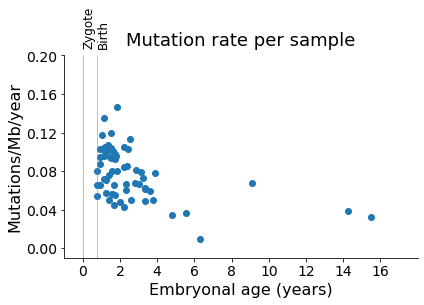

In [13]:
fig, ax = plt.subplots(figsize=(6,4))

excluded_sjd_samples = ['pt2_t1','pt9_t1','pt10_t1','pt14_t2','pt16_t1','pt18_t1','pt20_t1']
doublegermline_sample = ['PADYZI']
treated_samples = [pt for pt in ttmt_dict.keys() if ttmt_dict[pt]!='naive'] 
excluded_samples =  excluded_sjd_samples + doublegermline_sample + treated_samples
    
df = df3[~df3['sample'].isin(excluded_samples)]

age_values = df['age_embryo'].values
    
y = df[f'mutrate_clonal_age_embryo']
ax.scatter(age_values, y)
ax.set_ylabel('Mutations/Mb/year',size=16)
ax.set_xlabel('Embryonal age (years)',size=16)
ax.set_xlim(-1,18)
ax.set_ylim(-0.01,0.2)
plt.xticks(range(0,18,2),size=14)
plt.yticks(np.linspace(0,0.2,6),size=14)
plt.title('Mutation rate per sample',size=18,pad=10)

fig.tight_layout()

plt.axvline(3/4,color='grey',linewidth=0.5)
plt.axvline(0,color='grey',linewidth=0.5)
plt.text(3/4,0.21,s='Birth',rotation=90,size=12)
plt.text(0,0.21,s='Zygote',rotation=90,size=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig('plots/mutrate_per_sample.svg', bbox_inches='tight',format='svg')
plt.show()

In [14]:
import seaborn as sns
import scipy

In [15]:
df3['age_categorical'] = df3['age'].apply(lambda x: '0-2 year old' if x < 2 else '>2 year old')

In [16]:
def convert_pvalue_to_asterisks(pvalue):
    if pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    return "ns"

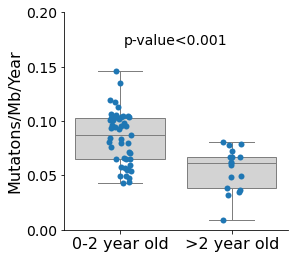

In [17]:
df = df3[~df3['sample'].isin(excluded_samples)]

stat, pvalue = scipy.stats.mannwhitneyu(
	df["mutrate_clonal_age_embryo"][(df['age_categorical'] == '0-2 year old')],
	df["mutrate_clonal_age_embryo"][(df["age_categorical"] == '>2 year old')]
)
fig,ax =plt.subplots(figsize=(4,4))
# plt.figure(figsize=(4,4))
sns.boxplot(data=df.sort_values('age_categorical',ascending=True), y='mutrate_clonal_age_embryo',x='age_categorical',color='lightgrey',saturation=0.5,fliersize=0)
sns.stripplot(data=df.sort_values('age_categorical',ascending=True), y='mutrate_clonal_age_embryo',x='age_categorical',color='#1f77b4',size=6)
plt.title('',size=16)
plt.ylabel('Mutatons/Mb/Year',size=16)
plt.xticks(size=16)
plt.yticks(np.linspace(0,0.2,num=5),size=14)
plt.xlabel('',size=14)
plt.ylim(0,0.2)
significance= convert_pvalue_to_asterisks(pvalue)
plt.text(s='p-value<0.001',x=0.5,y=0.85,ha='center',size=14,transform = ax.transAxes)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

out='plots/mutrate_diff_0_2_years.svg'
plt.savefig(out,dpi=300,bbox_inches='tight',format='svg')

In [18]:
import seaborn as sns
import statsmodels.api as sm
from scipy.optimize import curve_fit
from scipy.stats import linregress

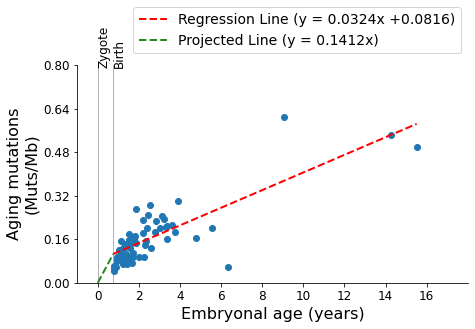

In [19]:
plt.figure(figsize=(7,4))

x_min = -1
x_max = 18
y_min = 0
y_max = 0.8

df = df3[~df3['sample'].isin(excluded_samples)]
    
age_ref = 'embryo'
age_col = 'age_embryo'
        
age_values = df[age_col].values

y = df[f'clonal_aging_sigs_per_mb']
plt.scatter(age_values, y, color='#1f77b4')
plt.ylabel('Aging mutations\n(Muts/Mb)',size=16)
plt.xlabel('embryo age (years)',size=16)
plt.title('')
plt.xlim(x_min,x_max)
plt.ylim(y_min,y_max)

plt.xticks(range(0,x_max,2),size=12)
plt.yticks(np.linspace(0,y_max,6),size=12)

df_filtered = df[(df['age_embryo'] > 0) & (df['clonal_aging_sigs_per_mb'] > 0)]
X = df_filtered['age_embryo']
y = df_filtered['clonal_aging_sigs_per_mb']
    
######## 2-step Linear regression fitting ################
# Fit 2 linear regressions:
# the first from 0 to 0.75, projected from the origin to the intercept of the other regression
# and the second from 0.75 onwards, calculated from the data points

# Perform linear regression for the second segment (age_embryo > 0.75)
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(X, y)

# Generate points for the regression line
x_vals2 = np.linspace(0.75, df['age_embryo'].max(), 100)
y_vals2 = slope2 * x_vals2 + intercept2

plt.plot(x_vals2, y_vals2, color='red', linestyle='--', linewidth=2, label=f'Regression Line (y = {slope2:.4f}x +{intercept2:.4f})')

# Define the points for the new line starting at the origin
x_vals1 = np.linspace(0, 0.75, 100)

y_value_at_075 = slope2 * 0.75 + intercept2
slope1 = (y_value_at_075-0)/(0.75-0)
y_vals1 = slope1 * x_vals1

# Plot the new line
plt.plot(x_vals1, y_vals1, color='forestgreen', linestyle='--', linewidth=2, label=f'Projected Line (y = {slope1:.4f}x)')

plt.axvline(3/4,color='dimgrey',linewidth=0.5)
plt.axvline(0,color='dimgrey',linewidth=0.5)
plt.text(3/4,0.8,s='Birth',rotation=90,size=12)
plt.text(0,0.8,s='Zygote',rotation=90,size=12)
plt.xlabel('Embryonal age (years)',size=16)

plt.legend(fontsize=14, bbox_to_anchor=(1, 1.3))

# fig.tight_layout()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

out='plots/two_slope_regression_mutrate.svg'
plt.savefig(out,dpi=300,bbox_inches='tight',format='svg')
plt.show()

In [20]:
# get a_log and b_log from logarythmic regression using non-treated samples

def get_slope_intercept (df,x_col,y_col):

	X = df[x_col]
	y = df[y_col]

	# Perform linear regression for the second segment (age_embryo > 0.75)
	slope2, intercept2, r_value, p_value, std_err = linregress(X, y)

	# Project line from 0 to 0.75
	y_value_at_075 = slope2 * 0.75 + intercept2
	slope1 = (y_value_at_075-0)/(0.75-0)
	return slope1, slope2, intercept2, y_value_at_075

In [21]:
slope1, slope2, intercept2, y_value_at_075 = get_slope_intercept(df3,'age_embryo','clonal_aging_sigs_per_mb')

In [22]:
map_per_mb_df.index

Index(['PAUDPV', 'PAVYKD', 'PASWZZ', 'PAEHIP', 'SJ030997', 'PASYNF', 'PARUGK',
       'PAWFWK', 'SJ031235', 'PARTKH', 'PASXNA', 'PAJLWM', 'PAREWI', 'PASZYE',
       'PAJNFP', 'PASCDH', 'PADWRZ', 'PAJMRB', 'PATXEE', 'pt6_t1', 'PAJNFZ',
       'pt6_t2', 'PAVCKS', 'PAUFVP', 'PMC01_t1', 'PMC01_t4', 'PMC01_t3',
       'PMC01_t2', 'PATENH', 'PAUNPA', 'pt8_t1', 'PARIRN', 'SJ032346',
       'pt15_t1'],
      dtype='object')

In [23]:
df3.index = df3['sample']
df4 = map_per_mb_df[['2','1','age']]
df5 = df4.merge(df3[['clonal_aging_sigs_per_mb','age_embryo']],how='left',left_index=True,right_index=True)

In [24]:
df3.index = df3['sample']
df4 = map_per_mb_df[['2','1','age']]
df5 = df4.merge(df3[['clonal_aging_sigs_per_mb','age_embryo','sample']],how='left',left_index=True,right_index=True)

df = df5.copy()

slope1, slope2, intercept2, y_value_at_075 = get_slope_intercept(df,'age_embryo','clonal_aging_sigs_per_mb')
print(slope1, slope2, intercept2, y_value_at_075)

for timing in ['before','after']:
	if timing == 'before':
		col = '2'
	else:
		col = '1'
	df['t_years_'+timing+'_event'] = df[col].apply(lambda y: y/slope1 if y < y_value_at_075 else (y - intercept2)/slope2)
	df['t_weeks_'+timing+'_event'] = df['t_years_'+timing+'_event'] *52 

df['t_years_mrca_event'] = df['t_years_before_event'] + df['t_years_after_event']
df['t_weeks_mrca_event'] = df['t_years_mrca_event'] *52 

df6 = df.sort_values('age',ascending=True)

0.14012044080229286 0.039480591611167085 0.07547988689334433 0.10509033060171964


In [25]:
samples_final_ids_dict = json.load(open("sample_ids/sample_ids_final.json", "rb"))

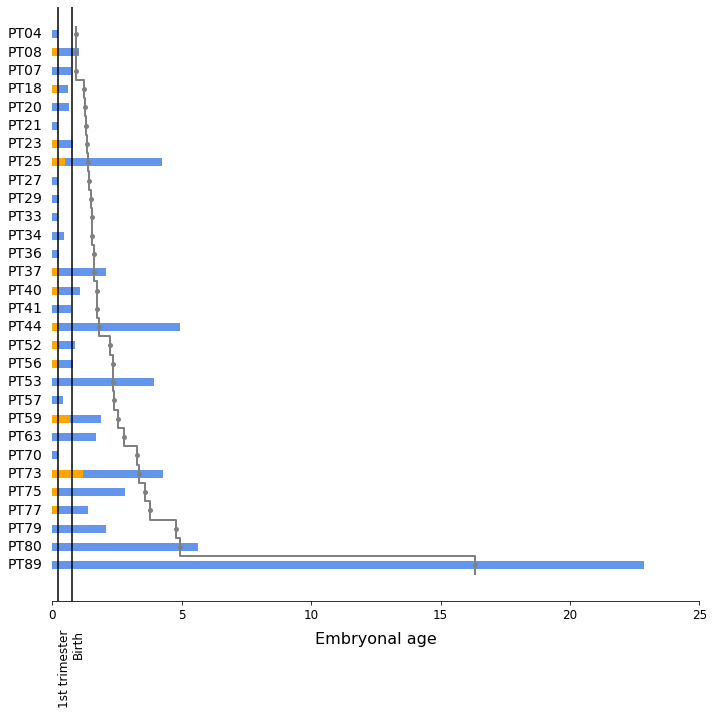

In [26]:
df1 = df6.copy()
def get_pt (sample):
    if sample.startswith('pt') or sample.startswith('PMC'):
        pt = sample.split('_')[0]
    else:
        pt = sample
    return pt
df1['pt'] = df1.index.map(get_pt)

treated_samples = ['pt7','SJ031948']

cnloh_pts = df1['pt'].drop_duplicates()

# 1. Prepare and Sort Data by Age
plot_data = []
for pt in cnloh_pts:
    if pt in treated_samples: continue
    suffix = '_t3' if pt == 'PMC01' else ('_t1' if pt.startswith('pt') else '')
    sample_id = pt + suffix
    if sample_id in df1.index:
        plot_data.append({
            'pt': pt,
            'burden': df1.loc[sample_id, 't_years_before_event'] + df1.loc[sample_id, 't_years_mrca_event'],
            'age': df1.loc[sample_id, 'age_embryo']
        })

# Sort by age so the step function flows correctly
plot_data = sorted(plot_data, key=lambda x: x['age'])
ages = [d['age'] for d in plot_data]
burdens = [d['burden'] for d in plot_data]

plt.figure(figsize=(10, 10))
ax1 = plt.gca()

y_coords = 0
for pt in cnloh_pts:
    if pt in treated_samples: continue
    
    sample_id = pt + ('_t3' if pt == 'PMC01' else ('_t1' if pt.startswith('pt') else ''))
    
    m_orange = df1.loc[sample_id, 't_years_before_event']
    m_blue = df1.loc[sample_id, 't_years_mrca_event']
    total_muts = m_orange + m_blue
    age_at_dx = df1.loc[sample_id, 'age_embryo']
    
    # Plot mutation segments on ax1
    ax1.hlines(y=y_coords, xmin=0, xmax=m_orange, color='orange', linewidth=8)
    ax1.hlines(y=y_coords, xmin=m_orange, xmax=total_muts, color='cornflowerblue', linewidth=8)
    
    # 2. Add a point or marker indicating Embryonal Age at Diagnosis
    ax1.plot(age_at_dx, y_coords, marker='.', color='grey', markersize=6, markeredgewidth=2)
    
    pt_final = samples_final_ids_dict[pt]
    ax1.text(-0.4, y_coords, pt_final, ha='right', va='center', size=14)
    y_coords -= 1

# Plot age as step function. The line is displaced by 0.5 to have the dot in the midle of the step line
ax1.step(ages, np.arange(-0.5, -len(plot_data)-0.5, -1), 
            where='post', color='grey', linestyle='-', 
            linewidth=2, label='Age Progression')
# Plot the first line
ax1.plot(ages[0], 0, marker='|', color='grey', markersize=16, markeredgewidth=2)

# 3. Align the Scales
# Set ax1 limit for mutation burden
ax1.set_xlim(0, 25)
ax1.set_xlabel('Embryonal age', size=16, labelpad=10)
ax1.tick_params(labelsize=12)

# Formatting
ax1.spines[['right', 'left','top']].set_visible(False)
ax1.set_yticks([])

ax1.axvline(12/52,c='k')
ax1.text(12/52,-32.5,s='1st trimester',size=12,ha='left',va='top',rotation=90)
ax1.axvline(40/52,c='k')
ax1.text(40/52,-32.5,s='Birth',size=12,ha='left',va='top',rotation=90)

plt.tight_layout()
plt.savefig('plots/cnloh_mrca_absolute_timing.svg', bbox_inches='tight',format='svg')
plt.show()

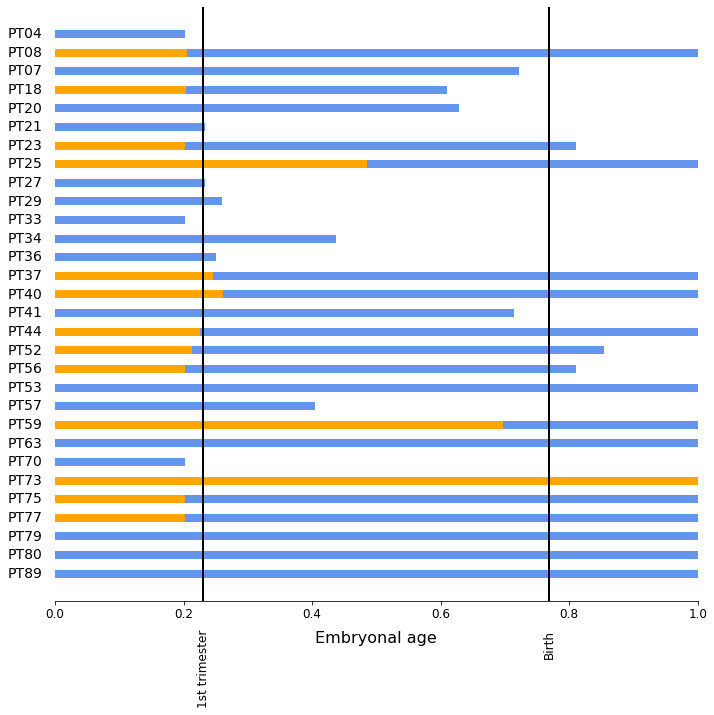

In [27]:
df1 = df6.copy()
def get_pt (sample):
    if sample.startswith('pt') or sample.startswith('PMC'):
        pt = sample.split('_')[0]
    else:
        pt = sample
    return pt
df1['pt'] = df1.index.map(get_pt)

cnloh_pts = df1['pt'].drop_duplicates()

# 1. Prepare and Sort Data by Age
plot_data = []
for pt in cnloh_pts:
    if pt in treated_samples: continue
    suffix = '_t3' if pt == 'PMC01' else ('_t1' if pt.startswith('pt') else '')
    sample_id = pt + suffix
    if sample_id in df1.index:
        plot_data.append({
            'pt': pt,
            'burden': df1.loc[sample_id, 't_years_before_event'] + df1.loc[sample_id, 't_years_mrca_event'],
            'age': df1.loc[sample_id, 'age_embryo']
        })

# Sort by age so the step function flows correctly
plot_data = sorted(plot_data, key=lambda x: x['age'])
ages = [d['age'] for d in plot_data]
burdens = [d['burden'] for d in plot_data]

plt.figure(figsize=(10, 10))
ax1 = plt.gca()

y_coords = 0
for pt in cnloh_pts:
    if pt in treated_samples: continue
    
    sample_id = pt + ('_t3' if pt == 'PMC01' else ('_t1' if pt.startswith('pt') else ''))
    
    m_orange = df1.loc[sample_id, 't_years_before_event']
    m_blue = df1.loc[sample_id, 't_years_mrca_event']
    total_muts = m_orange + m_blue
    age_at_dx = df1.loc[sample_id, 'age_embryo']
    
    # Plot mutation segments on ax1
    ax1.hlines(y=y_coords, xmin=0, xmax=m_orange, color='orange', linewidth=8)
    ax1.hlines(y=y_coords, xmin=m_orange, xmax=total_muts, color='cornflowerblue', linewidth=8)
    
    pt_final = samples_final_ids_dict[pt]
    ax1.text(-0.02, y_coords, pt_final, ha='right', va='center', size=14)
    y_coords -= 1

# 3. Align the Scales
# Set ax1 limit for mutation burden
ax1.set_xlim(0, 1)
ax1.set_xlabel('Embryonal age', size=16, labelpad=10)
ax1.tick_params(labelsize=12)

# Formatting
ax1.spines[['right', 'left','top']].set_visible(False)
ax1.set_yticks([])

ax1.axvline(12/52,c='k',linewidth=2)
ax1.text(12/52,-32,s='1st trimester',size=12,ha='center',va='top',rotation=90)
ax1.axvline(40/52,c='k',linewidth=2)
ax1.text(40/52,-32,s='Birth',size=12,ha='center',va='top',rotation=90)

plt.tight_layout()
plt.savefig('plots/cnloh_mrca_absolute_timing_closeup.svg', bbox_inches='tight',format='svg')
plt.show()

In [28]:
from scipy import stats

In [29]:
df1.index

Index(['PAUDPV', 'PAVYKD', 'PASWZZ', 'PAEHIP', 'SJ030997', 'PASYNF', 'PARUGK',
       'PAWFWK', 'SJ031235', 'PARTKH', 'PASXNA', 'PAJLWM', 'PAREWI', 'PASZYE',
       'PAJNFP', 'PASCDH', 'PADWRZ', 'PAJMRB', 'PATXEE', 'pt6_t1', 'PAJNFZ',
       'pt6_t2', 'PAVCKS', 'PAUFVP', 'PMC01_t1', 'PMC01_t4', 'PMC01_t3',
       'PMC01_t2', 'PATENH', 'PAUNPA', 'pt8_t1', 'PARIRN', 'SJ032346',
       'pt15_t1'],
      dtype='object')

In [30]:
df3

,sample,SBS1,SBS5,clonal_aging_sigs,age,SBS1_per_mb,SBS5_per_mb,clonal_aging_sigs_per_mb,2copies_mut_per_mb,1copy_mut_per_mb,CNLOH,cnloh_length,age_embryo,mutrate_clonal_age_embryo,age_categorical
sample,,,,,,,,,,,,,,,
PABKLN,PABKLN,72.0,617,689,1.10,0.028292,0.242444,0.270735,0.000000,0.000000,False,0.0,1.85,0.146343,0-2 year old
PADWRZ,PADWRZ,80.0,357,437,1.05,0.031435,0.140279,0.171715,0.031596,0.252768,True,31649585.0,1.80,0.095397,0-2 year old
PADYZI,PADYZI,0.0,0,0,2.97,0.000000,0.000000,0.000000,0.000000,0.000000,False,0.0,3.72,0.000000,>2 year old
PAEHIP,PAEHIP,62.0,118,180,0.48,0.024362,0.046367,0.070729,0.028479,0.028479,True,35114034.0,1.23,0.057503,0-2 year old
PAJLWM,PAJLWM,52.0,169,221,0.79,0.020433,0.066407,0.086840,0.000000,0.061315,True,32618353.0,1.54,0.056389,0-2 year old
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pt6_t2,pt6_t2,104.0,463,567,1.64,0.040866,0.181931,0.222797,0.000000,0.231929,True,30181611.0,2.39,0.093220,0-2 year old
pt7_t1,pt7_t1,0.0,0,0,2.25,0.000000,0.000000,0.000000,0.000000,0.000000,False,27000780.0,3.00,0.000000,>2 year old
pt8_t1,pt8_t1,157.0,318,475,3.02,0.061692,0.124955,0.186646,0.028389,0.113555,True,35225172.0,3.77,0.049508,>2 year old


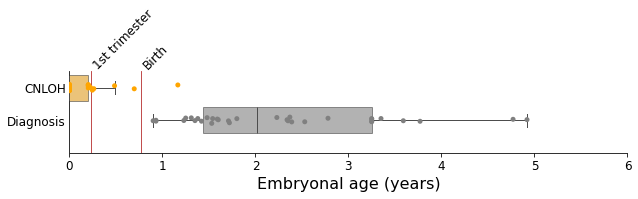

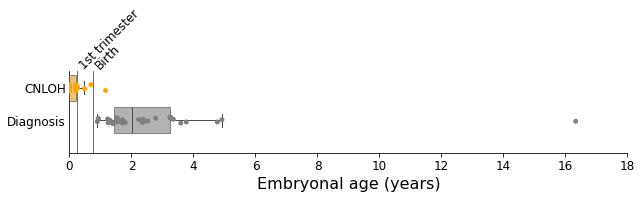

In [31]:
## Calculate mean and CI for CNLOH and clonal expansion

treated_samples = ['pt7_t1','SJ031948']
df2 = df1[~df1.index.isin(treated_samples)]

# for subset in ['total','clonals']:
# 	for option in ['all','nt']:
for xlim in [6,18]:
		
	fig, ax = plt.subplots(figsize=(10, 1.5))

	df3 = df2[['t_years_before_event', 't_years_after_event', 'age_embryo']]
	df3['t_years_MRCA_expansion'] = df3['t_years_before_event'] + df3['t_years_after_event']

	df3 = df3[['t_years_before_event','age_embryo']]

	color_dict = {'t_years_before_event':'orange',
				't_years_MRCA_expansion':'cornflowerblue',
				'age_embryo':'grey'}
	sns.boxplot(data=df3, orient='h',palette=color_dict,fliersize=0,boxprops=dict(alpha=.6))
	sns.stripplot(data=df3, orient='h',palette=color_dict)

	ax.axvline(0,color='k',linewidth=0.8)
	ax.axvline(12/52,color='firebrick',linewidth=0.8)
	ax.axvline(40/52,color='firebrick',linewidth=0.8)
	plt.text(12/52,-0.5,s='1st trimester',size=12,ha='left',va='bottom',rotation=45)
	plt.text(40/52,-0.5,s='Birth',size=12,ha='left',va='bottom',rotation=45)

	# Set the title, labels, and customize ticks for clarity
	ax.set_title('',size=14,pad=10)
	ax.set_xlabel('Embryonal age (years)',size=16)
	ax.set_ylabel('') # We will use custom labels
	ax.set_yticks([0,1,2])
	ax.set_yticklabels(['CNLOH','Diagnosis',''])
	ax.set_xlim([0,xlim])
	ax.tick_params(axis='x', labelsize=12)
	ax.tick_params(axis='y', labelsize=12,length=0)

	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	ax.spines['left'].set_visible(False)
	plt.savefig('plots/cnloh_absolute_timing_'+str(xlim)+'.svg', bbox_inches='tight',format='svg')
	plt.show()
